<a href="https://colab.research.google.com/github/Sagna112/zinc-flotation-recovery-prediction/blob/main/zinc_flotation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving zinc_flotation_dataset.csv to zinc_flotation_dataset.csv


In [3]:
import pandas as pd

# Loading the dataset into a DataFrame
df = pd.read_csv('zinc_flotation_dataset.csv')

# Display the first 5 rows
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head()


#IT GENERATED FIRST 5 ROWS OF THE DATASET TO SEE IF IT's valid data

Dataset shape: 1000 rows × 8 columns



,Feed_Grade_%Zn,pH,Collector_Dosage_g_t,Frother_Dosage_g_t,Air_Flow_Rate_m3_min,Impeller_Speed_RPM,Flotation_Time_min,Zinc_Recovery_%
0,5.48,8.60,58.5,17.3,22.7,1592,23.5,55.21
1,1.22,8.87,52.6,38.1,19.2,1633,21.2,49.65
2,4.81,9.38,102.5,49.5,8.1,1725,9.0,66.81
3,2.51,11.55,34.3,25.9,15.2,1252,20.1,79.01
4,6.65,11.42,95.1,58.5,15.6,1465,12.3,96.51


In [4]:
# Count missing values in each column
# print(df.isnull().sum())

# OR
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent
})

print(missing_summary)

#this cell code shows if there is any missing figure in the data

                      Missing Count  Missing Percentage (%)
Feed_Grade_%Zn                    0                     0.0
pH                                0                     0.0
Collector_Dosage_g_t              0                     0.0
Frother_Dosage_g_t                0                     0.0
Air_Flow_Rate_m3_min              0                     0.0
Impeller_Speed_RPM                0                     0.0
Flotation_Time_min                0                     0.0
Zinc_Recovery_%                   0                     0.0


Dataset shape: 1000 rows × 8 columns


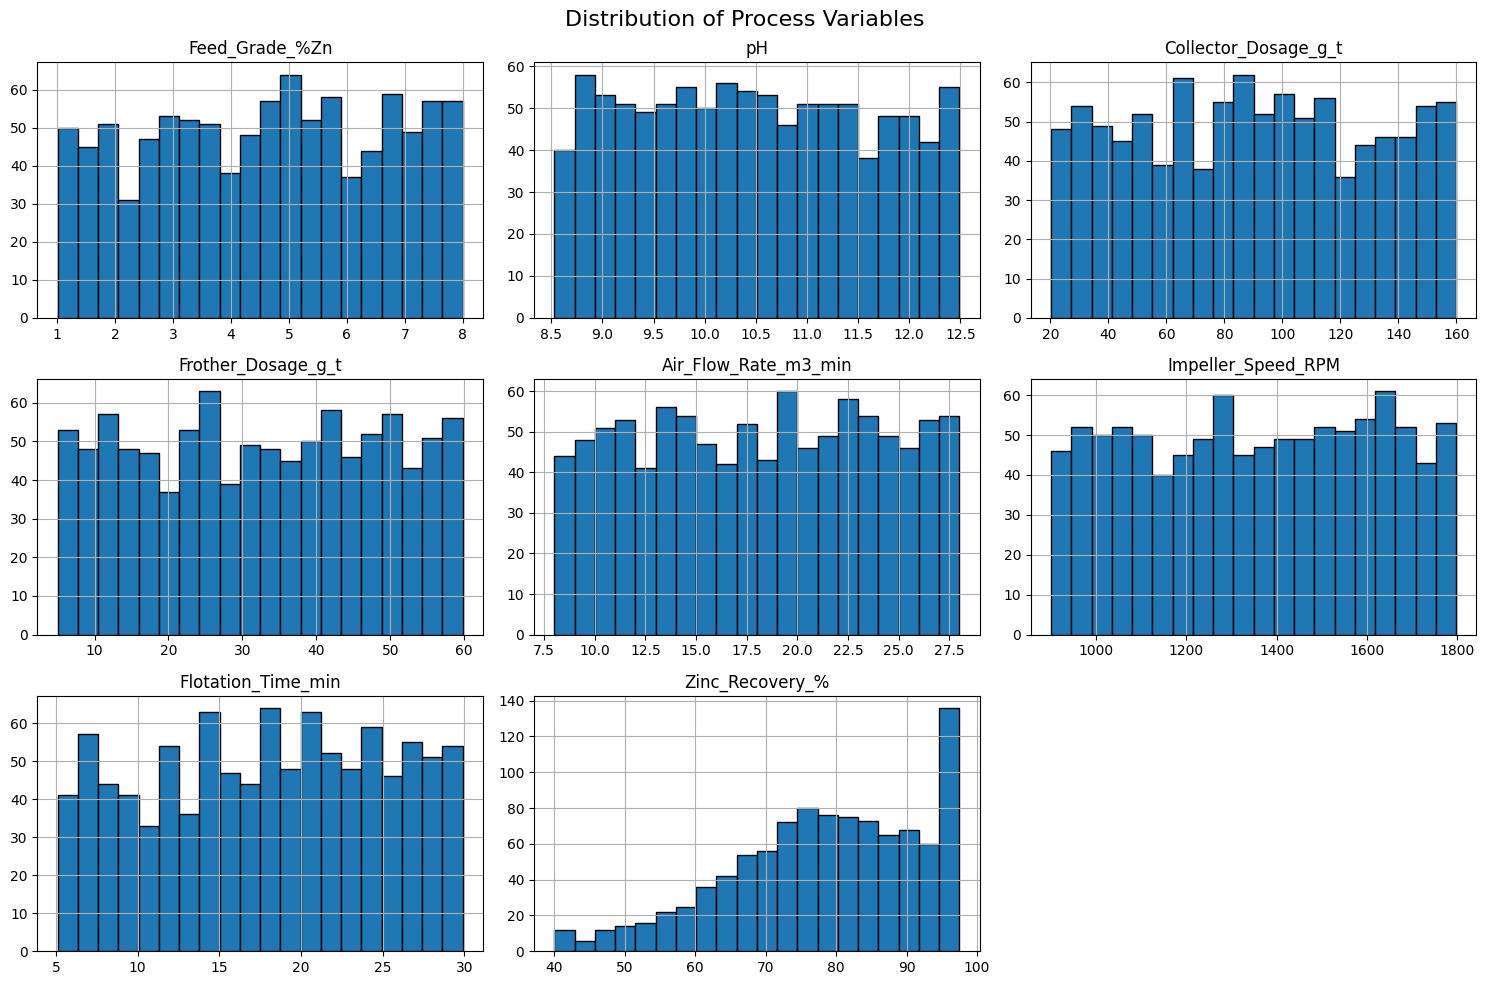

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# df = pd.read_csv('zinc_flotation_dataset.csv')

# Show dataset size
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Histograms
df.hist(
    bins=20,
    figsize=(15,10),
    edgecolor='black'
)

plt.suptitle('Distribution of Process Variables', fontsize=16)
plt.tight_layout()
plt.show()


#this code shows the histogram of each variables questions to ask here are
# is it symmetric or skewed , Are there outliers?

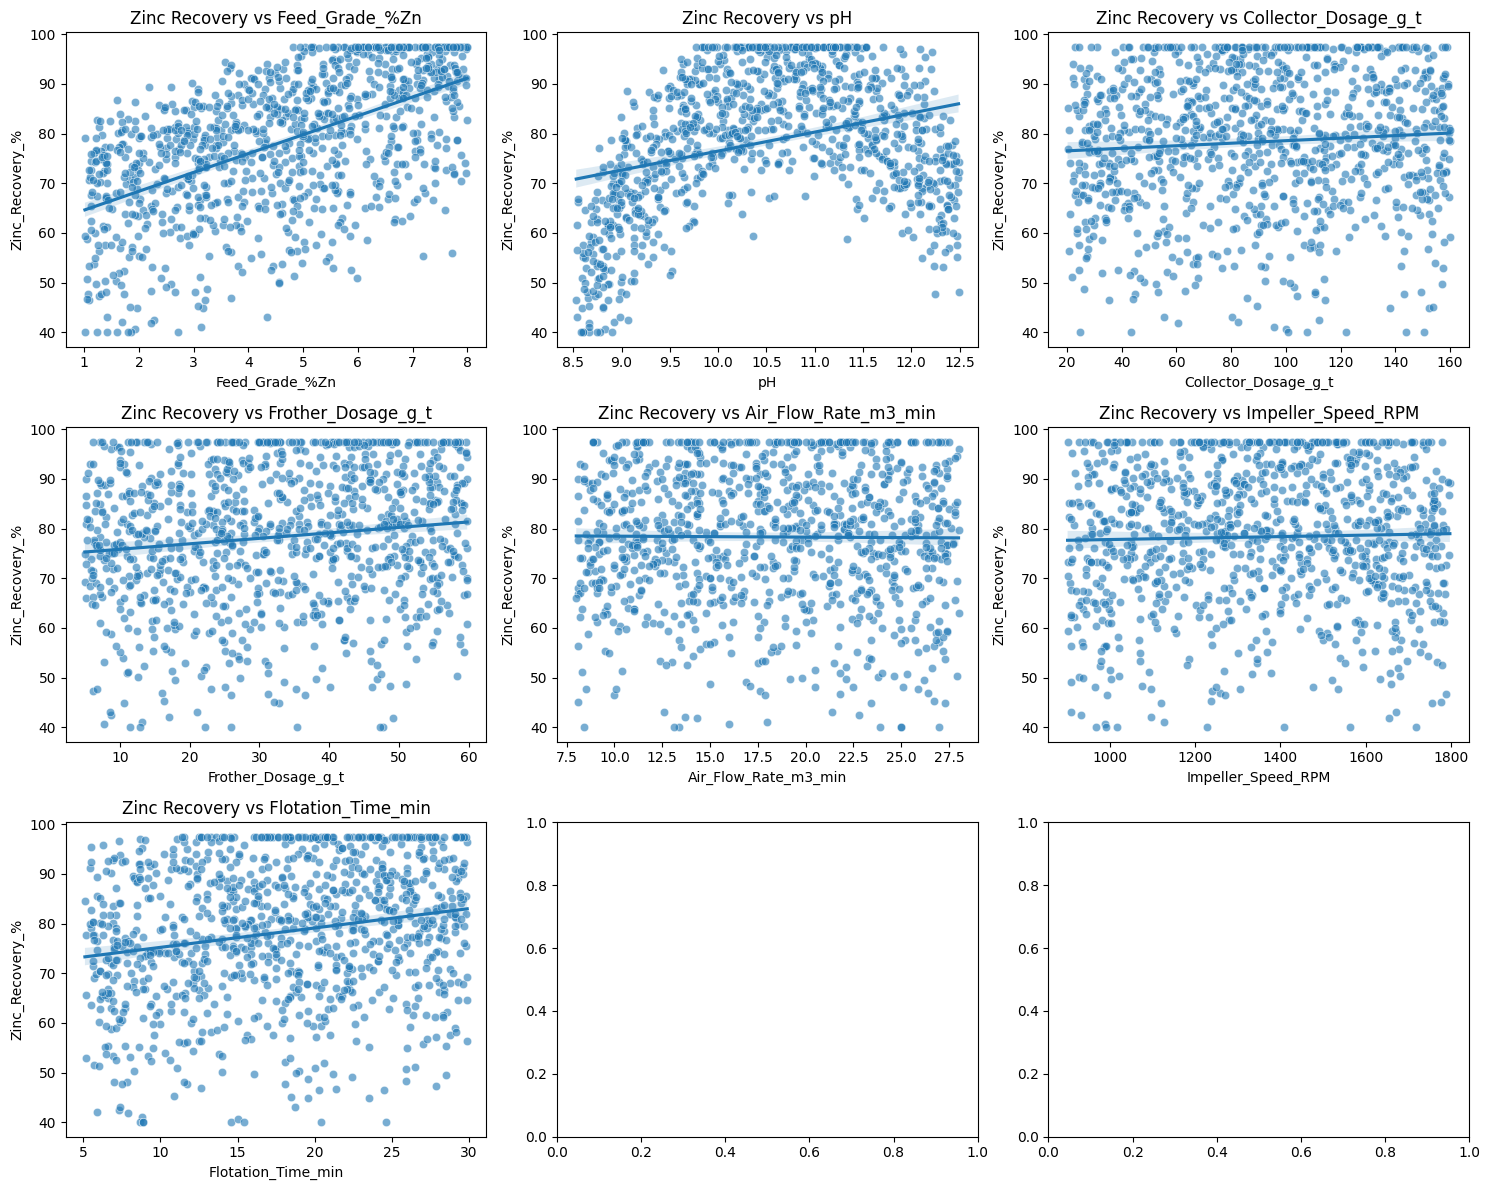

'   (| Rank| Variable             | Apparent Importance |\n| ---- | -------------------- | ------------------- |\n| 1    | Feed_Grade_%Zn       | Strong              |\n| 2    | pH                   | Strong              |\n| 3    | Flotation_Time_min   | Moderate            |\n| 4    | Collector_Dosage_g_t | Weak-Moderate       |\n| 5    | Frother_Dosage_g_t   | Weak                |\n| 6    | Air_Flow_Rate_m3_min | Very Weak           |\n| 7    | Impeller_Speed_RPM   | Very Weak           |\n 1. Higher zinc content in the feed tends to result in higher recovery.\n 2. There appears to be an optimal pH range around 10–11.\n 3. Collector dosage affects recovery, but not as strongly as Feed Grade or pH.\n 4.  Frother dosage has some influence, but the effect appears relatively small.\n 5.  Air flow rate may have little direct effect on recovery within the tested operating range.\n 6. Impeller speed appears to have minimal influence on recovery in this dataset.\n 7. Recovery generally inc

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    'Feed_Grade_%Zn',
    'pH',
    'Collector_Dosage_g_t',
    'Frother_Dosage_g_t',
    'Air_Flow_Rate_m3_min',
    'Impeller_Speed_RPM',
    'Flotation_Time_min'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for var, ax in zip(variables, axes.flatten()):
    sns.scatterplot(data=df, x=var, y='Zinc_Recovery_%', alpha=0.6, ax=ax)

    sns.regplot(
        data=df,
        x=var,
        y='Zinc_Recovery_%',
        scatter=False,
        ax=ax
    )

    ax.set_title(f'Zinc Recovery vs {var}')

plt.tight_layout()
plt.show()

#OUTPUT

"""   (| Rank| Variable             | Apparent Importance |
| ---- | -------------------- | ------------------- |
| 1    | Feed_Grade_%Zn       | Strong              |
| 2    | pH                   | Strong              |
| 3    | Flotation_Time_min   | Moderate            |
| 4    | Collector_Dosage_g_t | Weak-Moderate       |
| 5    | Frother_Dosage_g_t   | Weak                |
| 6    | Air_Flow_Rate_m3_min | Very Weak           |
| 7    | Impeller_Speed_RPM   | Very Weak           |
 1. Higher zinc content in the feed tends to result in higher recovery.
 2. There appears to be an optimal pH range around 10–11.
 3. Collector dosage affects recovery, but not as strongly as Feed Grade or pH.
 4.  Frother dosage has some influence, but the effect appears relatively small.
 5.  Air flow rate may have little direct effect on recovery within the tested operating range.
 6. Impeller speed appears to have minimal influence on recovery in this dataset.
 7. Recovery generally increases as flotation time increases.
 """

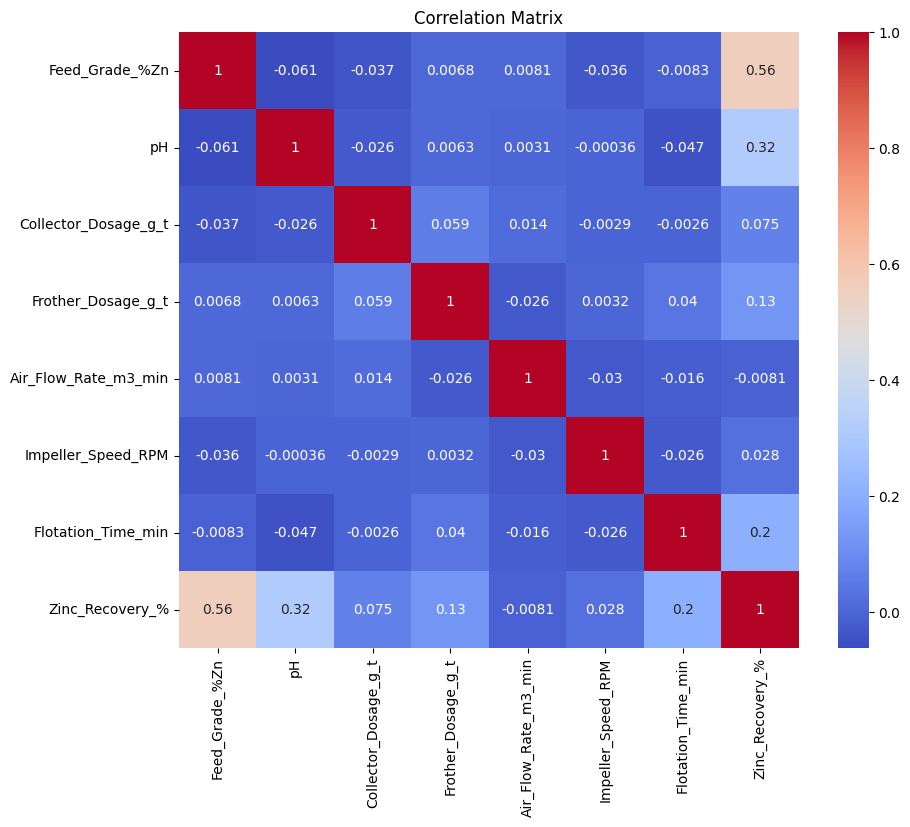

In [6]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


# Correlation Matrix Interpretation
#
# 1. Feed_Grade_%Zn shows the strongest positive correlation with Zinc_Recovery_% (r = 0.56),
#    indicating that higher feed grades generally lead to higher zinc recoveries.
#
# 2. pH has a moderate positive correlation with Zinc_Recovery_% (r = 0.32),
#    suggesting that pH plays an important role in flotation performance.
#
# 3. Flotation_Time_min exhibits a weak positive correlation (r = 0.20),
#    indicating that longer flotation times may slightly improve recovery.
#
# 4. Collector_Dosage_g_t (r = 0.075), Frother_Dosage_g_t (r = 0.13),
#    Impeller_Speed_RPM (r = 0.028), and Air_Flow_Rate_m3_min (r = -0.008)
#    show very weak or negligible linear relationships with Zinc_Recovery_%.
#
# 5. Correlations among the predictor variables are generally low,
#    indicating minimal multicollinearity and suggesting that the variables
#    provide largely independent information for predicting zinc recovery.
#
# Conclusion:
# Feed Grade and pH appear to be the most influential variables affecting
# zinc recovery, while the remaining variables show weaker direct linear relationships.
# These findings support their potential importance in the Random Forest model.

In [7]:
#split features and target
# Separate input features (X) from the target variable (y)

X = df.drop('Zinc_Recovery_%', axis=1)
y = df['Zinc_Recovery_%']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Feature names:  {list(X.columns)}")

# Separate predictor variables from the target variable.
# The predictor variables (X) represent flotation operating conditions,
# while the target variable (y) is Zinc Recovery (%),
# which the machine learning model will learn to predict.

Features shape: (1000, 7)
Target shape:   (1000,)
Feature names:  ['Feed_Grade_%Zn', 'pH', 'Collector_Dosage_g_t', 'Frother_Dosage_g_t', 'Air_Flow_Rate_m3_min', 'Impeller_Speed_RPM', 'Flotation_Time_min']


In [8]:
#Train / test split (80 / 20)
#Train the model on one part of the data and test it on unseen data.
#This code is preparing your data for training and evaluating a Machine Learning model.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held out for testing
    random_state=42   # reproducible split
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 800
Testing samples:  200


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,     # number of decision trees
    max_depth=None,       # trees grow fully (can tune later)
    min_samples_leaf=2,  # prevents overfitting on tiny leaves
    random_state=42
)

rf.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [23]:
# Evaluate model performance on unseen test data.
# R² measures how much variation in Zinc Recovery is explained by the model.
# MAE measures the average prediction error.
# RMSE measures prediction error while penalizing large mistakes more heavily.
# Lower MAE/RMSE and higher R² indicate better model performance.

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = rf.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   = {r2:.4f}   → model explains {r2*100:.1f}% of variance")
print(f"MAE  = {mae:.2f}%  → avg prediction error")
print(f"RMSE = {rmse:.2f}%  → penalises large errors more")

R²   = 0.9275   → model explains 92.7% of variance
MAE  = 2.85%  → avg prediction error
RMSE = 3.79%  → penalises large errors more


In [11]:
# Model Performance Summary:
# The Random Forest model achieved an R² score of 0.9275,
# indicating that approximately 92.75% of the variability in
# Zinc Recovery is explained by the input process variables.
#
# The MAE of 2.85% shows that predictions deviate from actual
# recovery values by about 2.85 percentage points on average.
#
# The RMSE of 3.79% suggests good predictive accuracy with
# relatively few large prediction errors.
#
# Overall, the model demonstrates strong performance and is
# capable of accurately predicting Zinc Recovery from the
# flotation process parameters.

In [13]:
actual_vs_pred = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(actual_vs_pred.head(10))

     Actual  Predicted
521   72.31  66.410818
737   97.50  95.849897
740   56.32  62.666653
660   85.25  83.669405
411   88.49  88.191189
678   79.03  78.140217
626   60.68  69.233520
513   74.10  75.594078
859   91.19  89.552625
136   91.16  89.831458


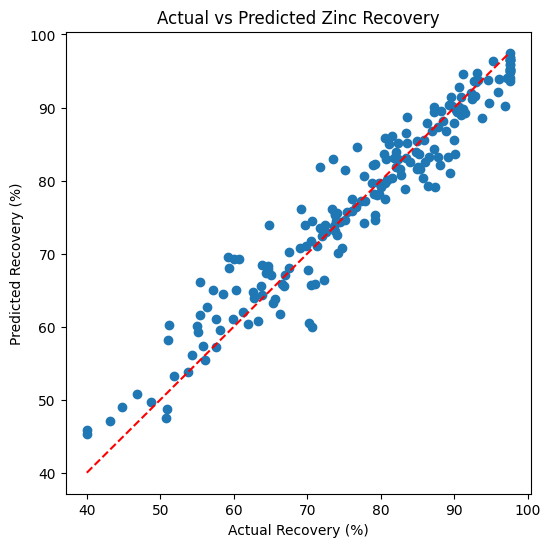

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Recovery (%)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Actual vs Predicted Zinc Recovery")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

In [ ]:
#interpretation
#The Actual vs Predicted plot demonstrates strong agreement between
#measured and predicted Zinc Recovery values. Most predictions
# lie close to the 1:1 reference line, indicating that the Random Forest model
# captures the underlying relationships between flotation operating variables
# and recovery. Prediction accuracy is particularly strong at higher recovery
# levels, with only minor deviations observed in the lower recovery region.

In [17]:
train_r2 = rf.score(X_train, y_train)
test_r2 = rf.score(X_test, y_test)

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")

#output interpretation
# The Random Forest model achieved an R² of 0.9829 on the
# training set and 0.9275 on the testing set.
#
# The relatively small difference between training and testing
# performance suggests that the model generalizes well to unseen
# data, with only minor overfitting.
#
# Therefore, the model is considered reliable for predicting
# Zinc Recovery using the available process variables.

Train R²: 0.9829
Test  R²: 0.9275


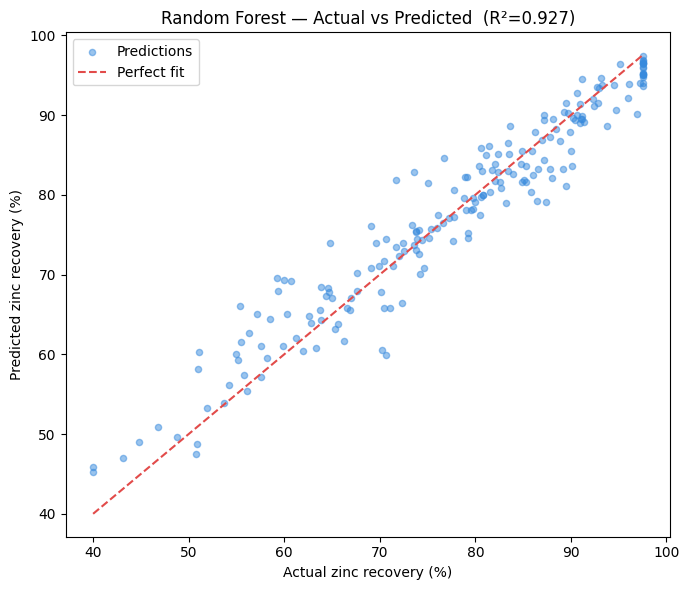

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred, alpha=0.5, s=20,
           color='#378ADD', label='Predictions')

# Perfect prediction line
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, '--', color='#E24B4A', lw=1.5, label='Perfect fit')

ax.set_xlabel('Actual zinc recovery (%)')
ax.set_ylabel('Predicted zinc recovery (%)')
ax.set_title(f'Random Forest — Actual vs Predicted  (R²={r2:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

#same as the above plot just a different code

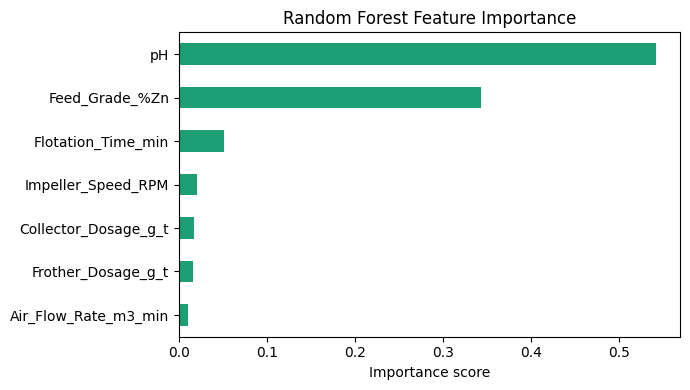


Importance ranking:
pH                      0.542484
Feed_Grade_%Zn          0.343148
Flotation_Time_min      0.051083
Impeller_Speed_RPM      0.020064
Collector_Dosage_g_t    0.016962
Frother_Dosage_g_t      0.015487
Air_Flow_Rate_m3_min    0.010772


In [19]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='#1D9E75', edgecolor='none')
ax.set_xlabel('Importance score')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("\nImportance ranking:")
print(importances.sort_values(ascending=False).to_string())

In [ ]:
#The Random Forest model identified pH as the most influential variable,
#contributing approximately 54% of the predictive importance.
#This is consistent with flotation theory, as pH strongly affects mineral surface chemistry,
# collector adsorption, and flotation selectivity. Feed grade was the second most influential variable
# at 34%, indicating that ore quality significantly impacts zinc recovery. Operational variables such as
# air flow rate, frother dosage, and collector dosage showed relatively low importance within the studied operating range.

In [20]:
# Simulate: what recovery do we expect from these plant conditions?
new_condition = pd.DataFrame([{
    'Feed_Grade_%Zn':       5.2,
    'pH':                   10.8,
    'Collector_Dosage_g_t': 85.0,
    'Frother_Dosage_g_t':   24.0,
    'Air_Flow_Rate_m3_min': 18.0,
    'Impeller_Speed_RPM':   1400,
    'Flotation_Time_min':   15.0,
}])

prediction = rf.predict(new_condition)[0]
print(f"Predicted zinc recovery: {prediction:.2f}%")

Predicted zinc recovery: 95.44%


In [21]:
scenarios = pd.DataFrame([
    {
        'Feed_Grade_%Zn': 5.2,
        'pH': 10.0,
        'Collector_Dosage_g_t': 85,
        'Frother_Dosage_g_t': 24,
        'Air_Flow_Rate_m3_min': 18,
        'Impeller_Speed_RPM': 1400,
        'Flotation_Time_min': 15
    },
    {
        'Feed_Grade_%Zn': 5.2,
        'pH': 11.0,
        'Collector_Dosage_g_t': 85,
        'Frother_Dosage_g_t': 24,
        'Air_Flow_Rate_m3_min': 18,
        'Impeller_Speed_RPM': 1400,
        'Flotation_Time_min': 15
    }
])

scenarios['Predicted_Recovery'] = rf.predict(scenarios)

print(scenarios)

   Feed_Grade_%Zn    pH  Collector_Dosage_g_t  Frother_Dosage_g_t  \
0             5.2  10.0                    85                  24   
1             5.2  11.0                    85                  24   

   Air_Flow_Rate_m3_min  Impeller_Speed_RPM  Flotation_Time_min  \
0                    18                1400                  15   
1                    18                1400                  15   

   Predicted_Recovery  
0           89.757207  
1           95.322891  
